In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset.csv')

# 1. Общая информация
print(df.shape)          # размер
print(df.dtypes)         # типы
print(df.isnull().sum()) # пропуски
print(df.describe())     # статистика

# 2. Распределение целевой переменной
df['target'].value_counts().plot(kind='bar')
plt.title('Распределение классов')
plt.savefig('class_dist.png', dpi=150)

# 3. Корреляционная матрица
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.savefig('correlation.png', dpi=150)


(1200, 13)
age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64
               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.00000

KeyError: 'target'

Всего изображений: 198
Мин: 512x512, Макс: 1080x1920


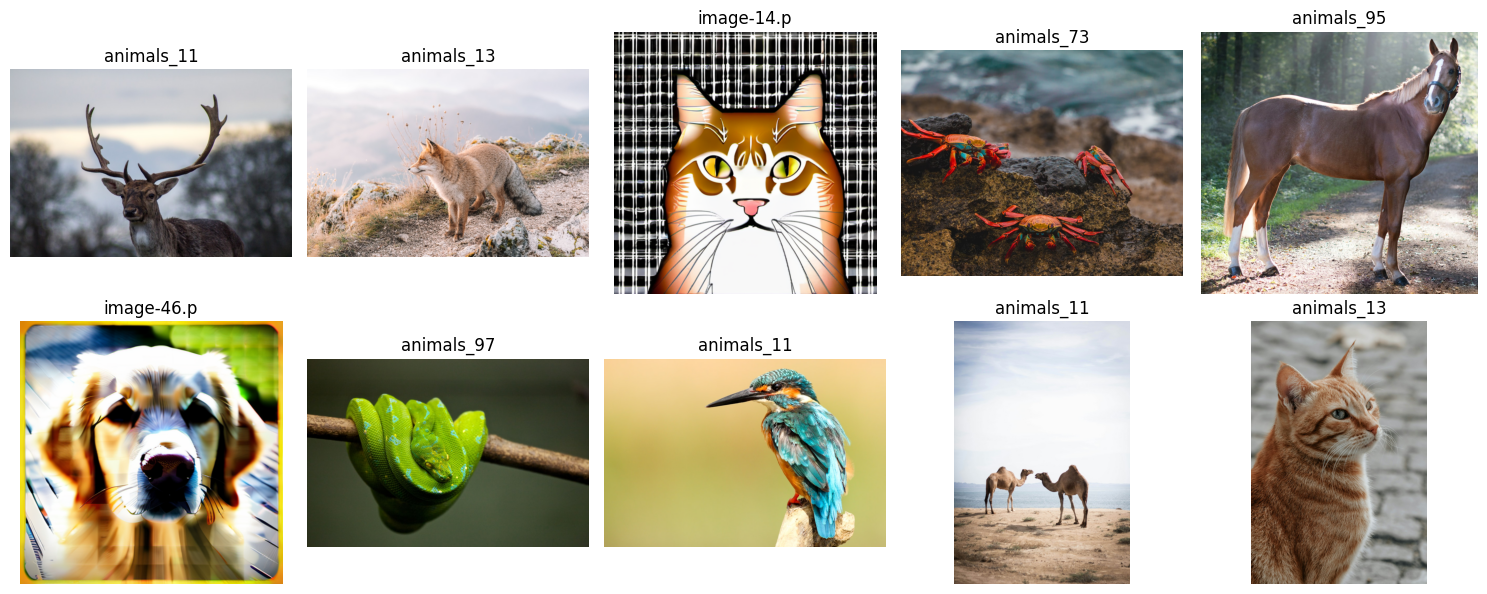

In [4]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 1. Анализ размеров изображений
base_path = 'images/' 
sizes = []

# Проверяем наличие папки
if not os.path.exists(base_path):
    print(f"Папка {base_path} не найдена!")
else:
    files = [f for f in os.listdir(base_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for f in files:
        with Image.open(os.path.join(base_path, f)) as img:
            sizes.append(img.size)

    print(f"Всего изображений: {len(sizes)}")

    if sizes:
        widths, heights = zip(*sizes)
        print(f'Мин: {min(widths)}x{min(heights)}, Макс: {max(widths)}x{max(heights)}')

        # 2. Показ примеров
        # Выбираем 10 случайных изображений из списка files
        num_samples = min(10, len(files))
        samples = random.sample(files, num_samples)

        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        
        for ax, sample_name in zip(axes.flat, samples):
            img_path = os.path.join(base_path, sample_name)
            img = Image.open(img_path)
            ax.imshow(img)
            # Укорачиваем название файла для заголовка
            ax.set_title(sample_name[:10]) 
            ax.axis('off')
        
        # Скрываем лишние оси, если картинок меньше 10
        for i in range(len(samples), 10):
            axes.flat[i].axis('off')

        plt.tight_layout()
        plt.savefig('samples_grid.png', dpi=150)
        plt.show()
    else:
        print("Изображения не найдены в папке images/.")